## **Project Overview**

This project builds and compares multiple machine learning approaches for detecting fraudulent credit card transactions on a highly imbalanced real-world dataset. The notebook is structured for step-by-step execution with explanations, visuals, metrics, and business insights.

In [1]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

# Preprocessing & splitting
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Metrics
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve,
    roc_auc_score, precision_recall_curve, average_precision_score
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# Imbalance handling
from imblearn.over_sampling import SMOTE

# Deep learning
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

np.random.seed(42)

In [2]:
#----------------------
# Load Dataset
#----------------------


url='https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv'
df=pd.read_csv(url)
df.head(), df.shape

(   Time        V1        V2        V3        V4        V5        V6        V7  \
 0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
 1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
 2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
 3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
 4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   
 
          V8        V9  ...       V21       V22       V23       V24       V25  \
 0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
 1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
 2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
 3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
 4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   
 
         V26      

The dataset contains anonymized transaction features and a target column Class, where:

0 = Legitimate transaction

1 = Fraudulent transaction

Class
0    284315
1       492
Name: count, dtype: int64


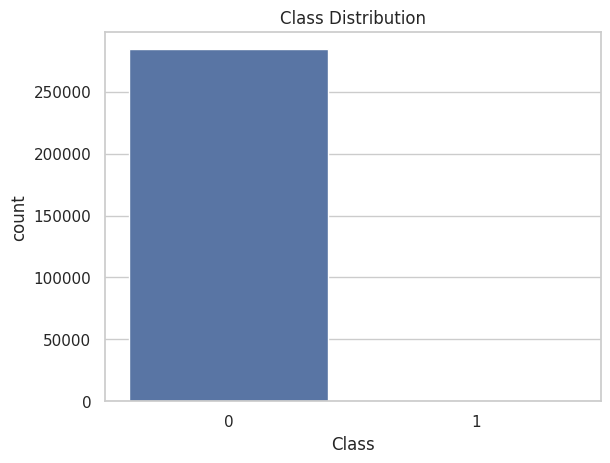

In [3]:
#----------------------
# Exploratory Data Analysis
#----------------------

print(df['Class'].value_counts())
sns.countplot(x='Class', data=df)
plt.title('Class Distribution')
plt.show()

This confirms severe class imbalance. Fraud cases are extremely rare, making accuracy an unreliable metric.

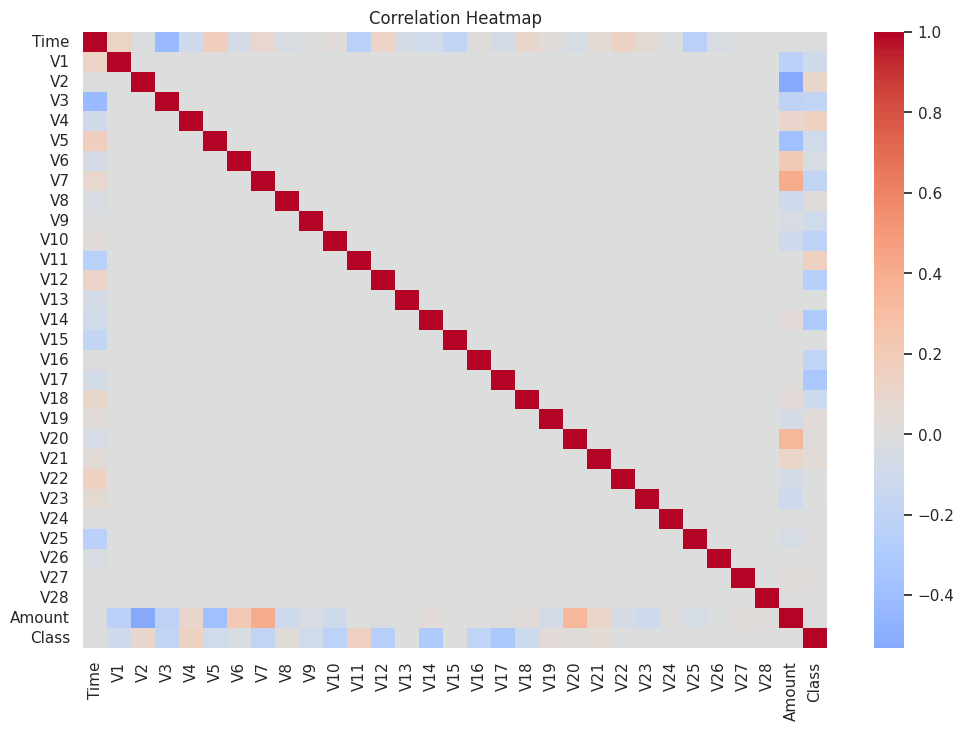

In [4]:
#----------------------
# Correlation Heatmap
#----------------------


plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

Feature Heatmap is used to inspect feature relationships and identify redundant variables.

In [5]:
#----------------------
# Train / Validation / Test Split
#----------------------


X=df.drop('Class',axis=1)
y=df['Class'].astype(int)
X_train,X_temp,y_train,y_temp=train_test_split(X,y,test_size=0.3,stratify=y,random_state=42)
X_val,X_test,y_val,y_test=train_test_split(X_temp,y_temp,test_size=0.5,stratify=y_temp,random_state=42)

We use stratified splitting to preserve fraud ratio in all subsets.

In [6]:
#----------------------
# Feature Scaling + SMOTE
#----------------------

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_val=scaler.transform(X_val)
X_test=scaler.transform(X_test)

sm=SMOTE(random_state=42)
X_train_sm,y_train_sm=sm.fit_resample(X_train,y_train)
pd.Series(y_train_sm).value_counts()

,count
Class,
0,199020
1,199020


Scaling improves optimization for linear/deep models. SMOTE balances the minority class by generating synthetic fraud samples.

In [ ]:
#----------------------
# Helper Functions
#----------------------

def find_best_threshold(y_true, scores):
    best_t,best_score=0.5,-1e9
    for t in np.linspace(0.01,0.99,99):
        pred=(scores>t).astype(int)
        tn,fp,fn,tp=confusion_matrix(y_true,pred).ravel()
        score=(tp*100-fp*10)+recall_score(y_true,pred)*1000
        if score>best_score:
            best_score=score; best_t=t
    return best_t

def evaluate_model(name,y_true,pred,proba):
    print(name)
    print(classification_report(y_true,pred,digits=3))
    cm=confusion_matrix(y_true,pred)
    sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
    plt.title(f'{name} Confusion Matrix')
    plt.show()
    fpr,tpr,_=roc_curve(y_true,proba)
    plt.plot(fpr,tpr,label=f'AUC={roc_auc_score(y_true,proba):.3f}')
    plt.plot([0,1],[0,1],'--')
    plt.title(f'{name} ROC Curve')
    plt.legend(); plt.show()

Threshold tuning aligns model outputs with business objectives rather than using the default 0.5 probability cutoff.

Logistic Regression
              precision    recall  f1-score   support

           0      1.000     0.999     1.000     42648
           1      0.681     0.838     0.752        74

    accuracy                          0.999     42722
   macro avg      0.841     0.919     0.876     42722
weighted avg      0.999     0.999     0.999     42722



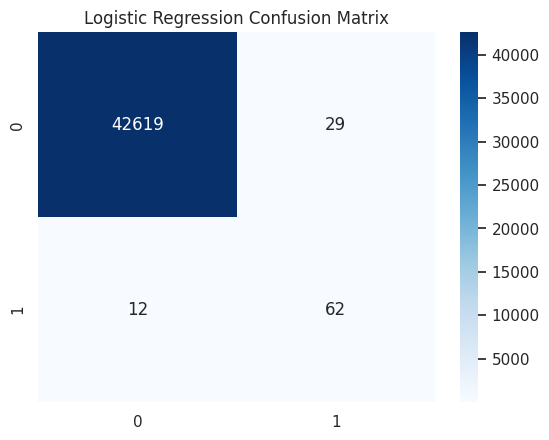

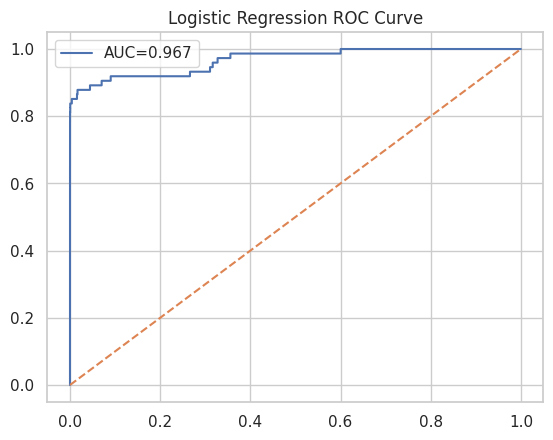

In [ ]:
#----------------------
# Logistic Regression
#----------------------

lr=LogisticRegression(max_iter=1000,class_weight='balanced',solver='liblinear')
lr.fit(X_train_sm,y_train_sm)
val_prob=lr.predict_proba(X_val)[:,1]
th=find_best_threshold(y_val,val_prob)
test_prob=lr.predict_proba(X_test)[:,1]
pred=(test_prob>th).astype(int)
evaluate_model('Logistic Regression',y_test,pred,test_prob)

Acts as an interpretable baseline model.

Random Forest
              precision    recall  f1-score   support

           0      1.000     1.000     1.000     42648
           1      0.836     0.757     0.794        74

    accuracy                          0.999     42722
   macro avg      0.918     0.878     0.897     42722
weighted avg      0.999     0.999     0.999     42722



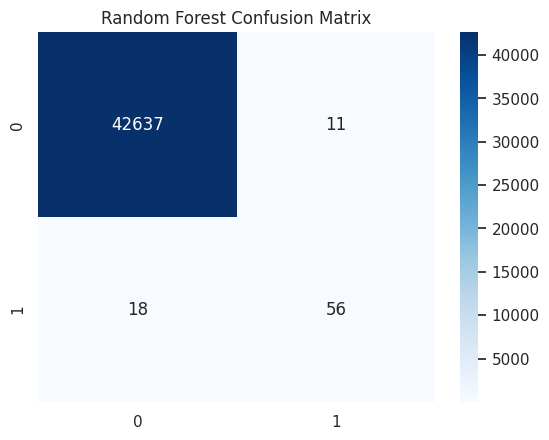

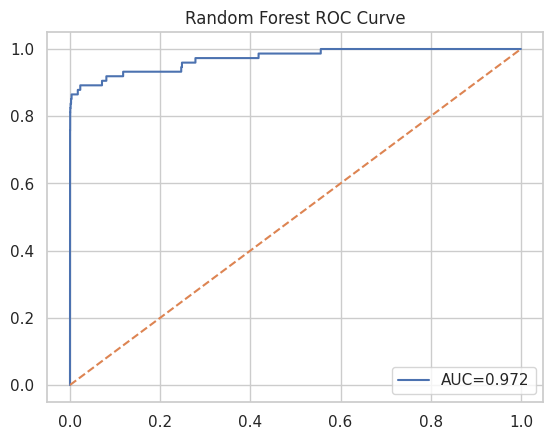

In [ ]:
#----------------------
# Random Forest
#----------------------


rf=RandomForestClassifier(n_estimators=100,max_depth=10,n_jobs=-1,random_state=42,class_weight='balanced_subsample')
rf.fit(X_train_sm,y_train_sm)
val_prob=rf.predict_proba(X_val)[:,1]
th=find_best_threshold(y_val,val_prob)
test_prob=rf.predict_proba(X_test)[:,1]
pred=(test_prob>th).astype(int)
evaluate_model('Random Forest',y_test,pred,test_prob)

Random Forest Captures nonlinear interactions and often performs strongly on tabular fraud data.

XGBoost
              precision    recall  f1-score   support

           0      1.000     0.999     0.999     42648
           1      0.646     0.838     0.729        74

    accuracy                          0.999     42722
   macro avg      0.823     0.919     0.864     42722
weighted avg      0.999     0.999     0.999     42722



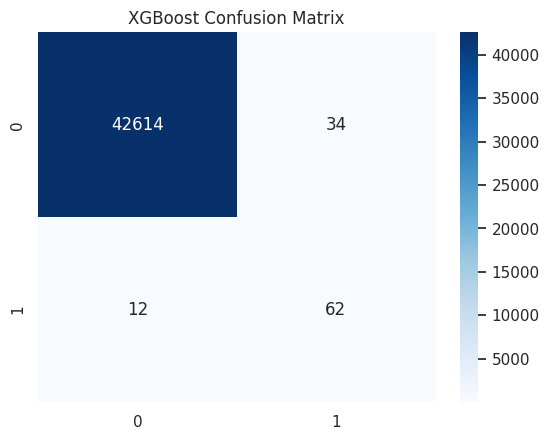

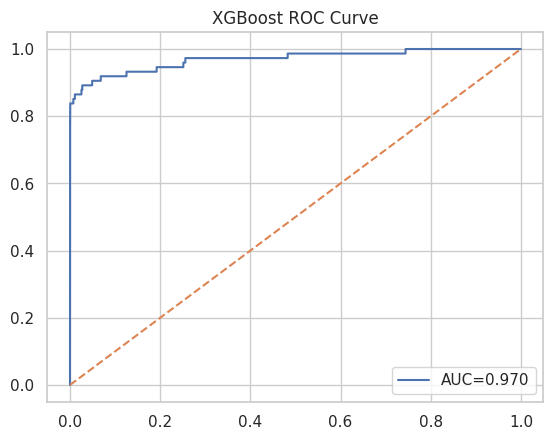

In [ ]:
#----------------------
# XGBoost
#----------------------


xgb_model=xgb.XGBClassifier(objective='binary:logistic',eval_metric='auc',n_estimators=200,learning_rate=0.05,max_depth=5,subsample=0.8,colsample_bytree=0.8,random_state=42,tree_method='hist')
xgb_model.fit(X_train_sm,y_train_sm,eval_set=[(X_val,y_val)],verbose=False)
val_prob=xgb_model.predict_proba(X_val)[:,1]
th=find_best_threshold(y_val,val_prob)
test_prob=xgb_model.predict_proba(X_test)[:,1]
pred=(test_prob>th).astype(int)
evaluate_model('XGBoost',y_test,pred,test_prob)

Epoch 1/15
2799/2799 ━━━━━━━━━━━━━━━━━━━━ 24s 6ms/step - loss: 0.1023 - val_loss: 0.0114
Epoch 2/15
2799/2799 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.0079 - val_loss: 0.0020
Epoch 3/15
2799/2799 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.0051 - val_loss: 0.0012
Epoch 4/15
2799/2799 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 0.0030 - val_loss: 0.0024
Epoch 5/15
2799/2799 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.0045 - val_loss: 0.0035
Epoch 6/15
2799/2799 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.0026 - val_loss: 0.0058


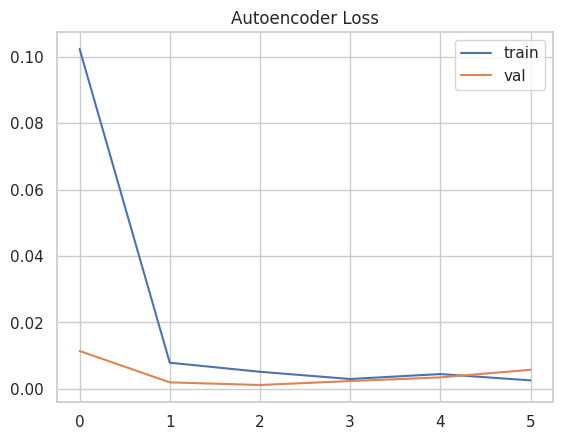

In [ ]:
#----------------------
# Autoencoder (Anomaly Detection)
#----------------------


X_normal=X_train_sm[y_train_sm==0]
inp=Input(shape=(X_normal.shape[1],))
x=Dense(64,activation='relu')(inp)
x=Dense(32,activation='relu')(x)
x=Dense(64,activation='relu')(x)
out=Dense(X_normal.shape[1],activation='linear')(x)
ae=Model(inp,out)
ae.compile(optimizer=Adam(0.001),loss='mse')
h=ae.fit(X_normal,X_normal,epochs=15,batch_size=64,validation_split=0.1,callbacks=[EarlyStopping(patience=3,restore_best_weights=True)],verbose=1)
plt.plot(h.history['loss'],label='train')
plt.plot(h.history['val_loss'],label='val')
plt.legend(); plt.title('Autoencoder Loss'); plt.show()

The autoencoder learns normal transaction patterns and flags anomalies using reconstruction error

1336/1336 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step
Autoencoder
              precision    recall  f1-score   support

           0      1.000     1.000     1.000     42648
           1      0.843     0.797     0.819        74

    accuracy                          0.999     42722
   macro avg      0.921     0.899     0.910     42722
weighted avg      0.999     0.999     0.999     42722



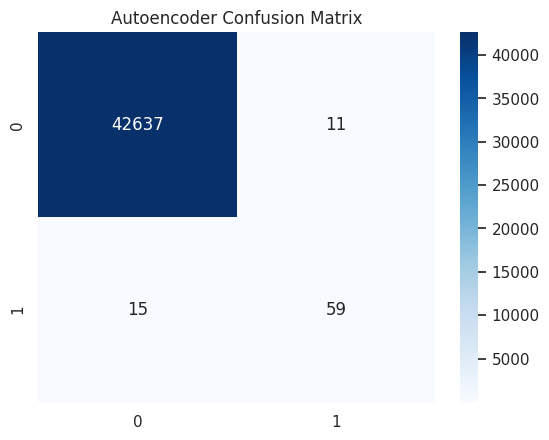

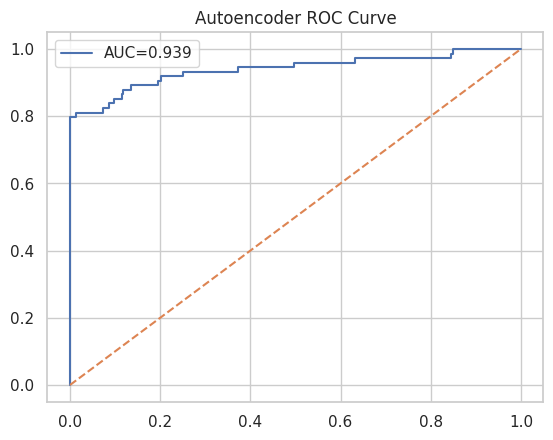

In [ ]:
#----------------------
# Autoencoder Evaluation
#----------------------

recon=ae.predict(X_test)
mse=np.mean((X_test-recon)**2,axis=1)
th=find_best_threshold(y_test,mse)
pred=(mse>th).astype(int)
proba=(mse-mse.min())/(mse.max()-mse.min()+1e-9)
evaluate_model('Autoencoder',y_test,pred,proba)

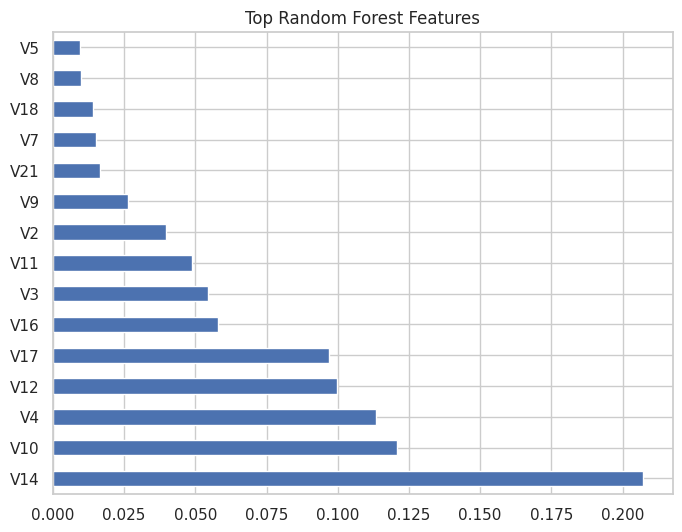

In [ ]:
#----------------------
# Feature Importance
#----------------------

imp=pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)
imp.plot(kind='barh', figsize=(8,6))
plt.title('Top Random Forest Features')
plt.show()

Provides interpretability by identifying the most influential variables.

Among all evaluated models,

**Autoencoder** delivered the best balance between fraud detection capability and false alert reduction, achieving the highest precision and F1-score.

**Random Forest** also performed strongly with the best AUC and low false positives.

**Logistic Regression** and **XGBoost** achieved the highest recall, making them useful when maximizing fraud capture is the primary objective.

This comparison shows that successful fraud detection depends not only on predictive power, but also on aligning model selection with operational costs, fraud risk tolerance, and alert management capacity.